In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk

In [2]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000, 100000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [3]:
hdata

HData object with 0 cells and 0 metacells
    resolutions: [50000, 100000, 500000, 1000000]
    obs: []
    views_pca: []
    views_umap: []
    views_embedding: []
    uns keys: []

In [4]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======


====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 100000 =======
Files for resolution 100000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [5]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [6]:
hdata.obs['label'] = lb

In [7]:
hdata

HData object with 700 cells and 0 metacells
    resolutions: [50000, 100000, 500000, 1000000]
    obs: ['depth', 'label']
    views_pca: [50000, 100000, 500000, 1000000]
    views_umap: [50000, 100000, 500000, 1000000]
    views_embedding: [50000, 100000, 500000, 1000000]
    uns keys: []

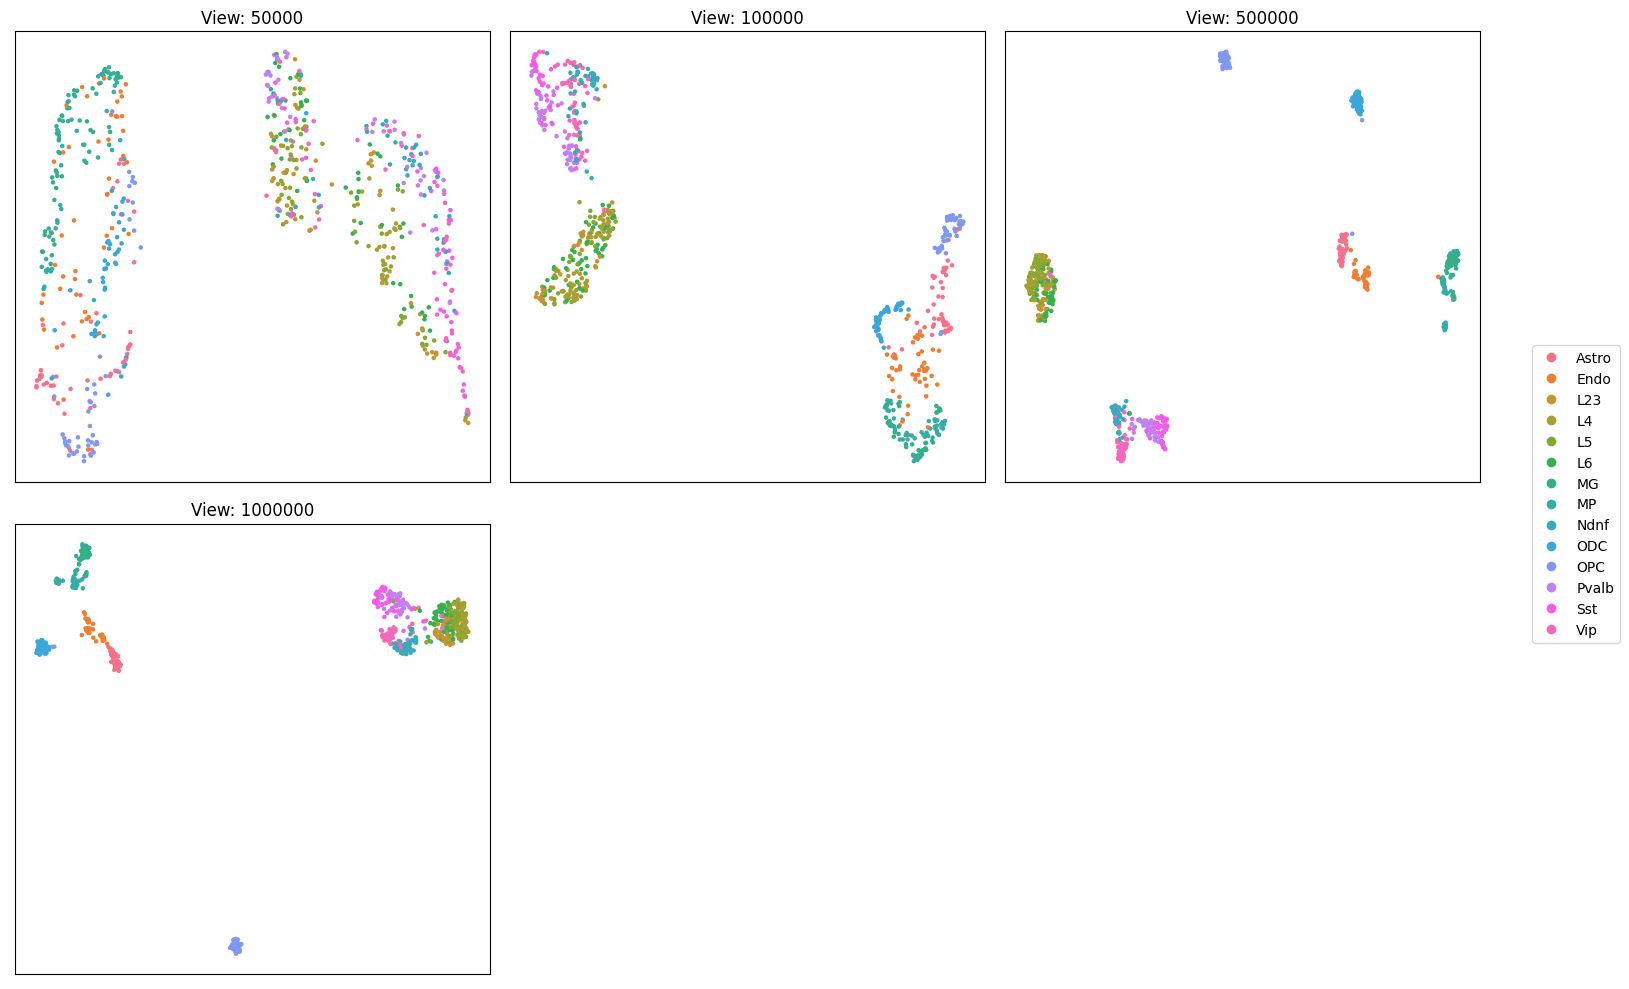

In [8]:
sk.pl.plot_views(hdata)

mean_depth:0.11M


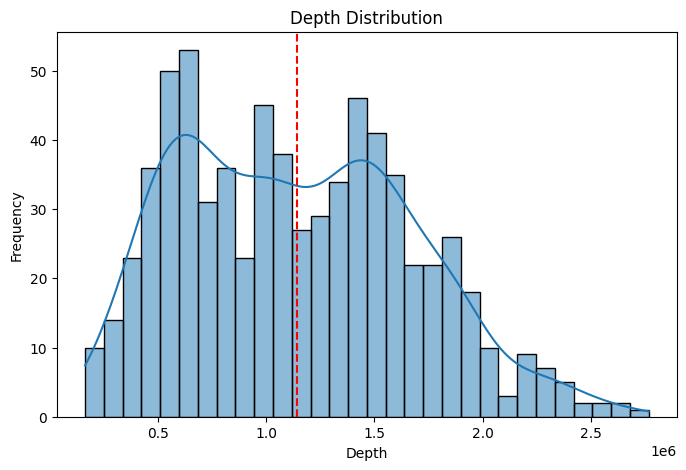

In [9]:
sk.pl.plot_depth_distribution(hdata)


>>> 2. 推荐 MetaCell 数量...
推荐 MetaCell 数量的目标测序深度范围: 10000000.00 - 100000000.00
正在构建 AnnData 并计算近邻图 (n_neighbors=15)...
正在执行 Leiden 聚类 (resolution=2.0)...
✅ 聚类完成，共发现 15 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [15, 75]


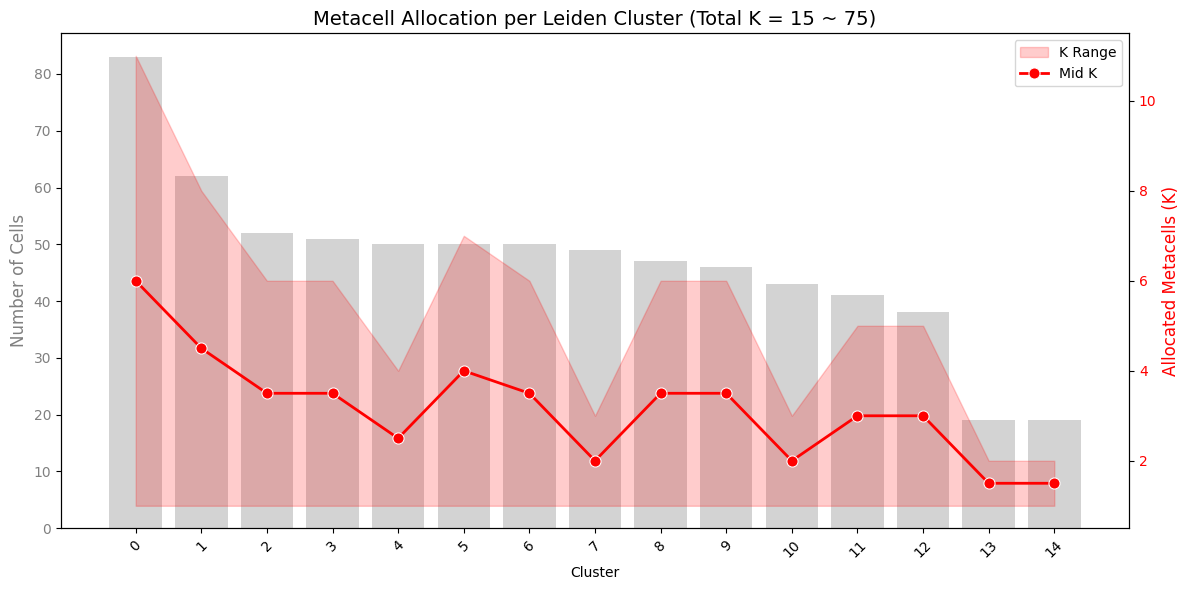

In [10]:
# ==========================================
# 2. 推荐 MetaCell 数量 (带原有参数)
# ==========================================
print("\n>>> 2. 推荐 MetaCell 数量...")
min_depth = 10000000
max_depth = 100000000
print(f"推荐 MetaCell 数量的目标测序深度范围: {min_depth:.2f} - {max_depth:.2f}")
min_k, max_k = sk.tl.recommend_metacell_num(
    hdata,
    target_depth_min=min_depth,  # 下限 20M
    target_depth_max=max_depth ,  # 上限 40M
    resolution_param=2.0,     # Leiden resolution
    n_neighbors=15,
    ref_view=1000000
)

In [11]:



# ==========================================
# 3. 初始化模型参数 (还原所有原有超参数)
# ==========================================
print("\n>>> 3. 初始化模型参数...")
sk.tl.init_model(
    hdata, 
    n_metacells=20,            # 目标 MetaCell 数量
    lambda_sparse=0.0000,      # 稀疏惩罚
    lambda_balance=0.01,       # 平衡惩罚
    lambda_consistency=0.001,  # 一致性惩罚
    max_iter=100,              # 最大迭代次数
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002,  # 重生阈值
    respawn_interval=10,       # 检查频率
    split_metric='pca'         # 分裂准则
)


>>> 3. 初始化模型参数...
✅ 模型参数初始化完成，目标 MetaCell 数量: 20


In [12]:


# ==========================================
# 4. 计算核矩阵
# ==========================================
print("\n>>> 4. 计算核矩阵...")
sk.tl.compute_kernels(hdata)



>>> 4. 计算核矩阵...
步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 84))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 1] 开始内部计算 RBF 核矩阵 (Input: (700, 114))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 2] 开始内部计算 RBF 核矩阵 (Input: (700, 123))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0



>>> 5. 初始化 Waypoints (K-Means++)...

步骤2: 参数初始化 (Data: kernel, Method: Micro-Clustering)
  正在合并核矩阵用于初始化...
  执行 MiniBatchKMeans (k=30)...
  最终选中 20 个 Waypoints


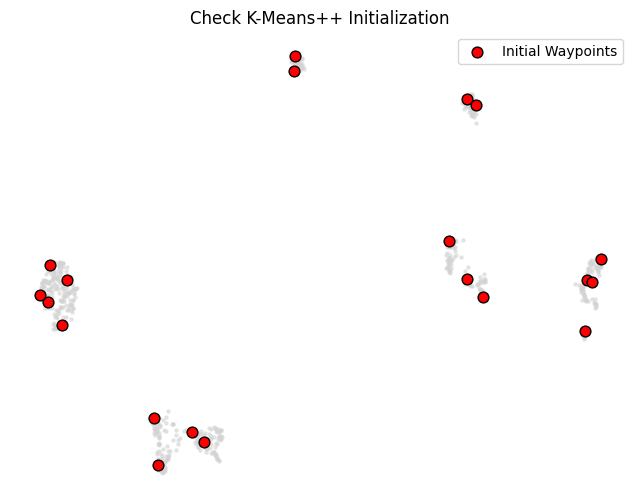

In [13]:
# ==========================================
# 5. 初始化 Waypoint (还原原有初始化参数)
# ==========================================
print("\n>>> 5. 初始化 Waypoints (K-Means++)...")
sk.tl.initialize_waypoints(
    hdata, 
    seed=32, 
    n_micro_clusters=30,       # 对应原代码中的 30
    ref_view_res=500000
)
sk.pl.plot_initialization(hdata,resolution=500000, title="Check K-Means++ Initialization")



In [14]:



# ==========================================
# 6. 核心拟合优化
# ==========================================
print("\n>>> 6. 开始模型拟合优化...")
sk.tl.fit(hdata, n_threads=10)


>>> 6. 开始模型拟合优化...

步骤4: 联合优化 (Split Metric: pca)
Iter   0 | Loss: 1602.6677 | Size Range: 30.5-37.9
Iter  10 | Loss: 1450.9891 | Size Range: 30.6-43.2
Iter  20 | Loss: 1441.9732 | Size Range: 30.2-40.1
Iter  30 | Loss: 1448.2630 | Size Range: 29.4-40.7
Iter  40 | Loss: 1446.6293 | Size Range: 29.6-41.6
Iter  50 | Loss: 1437.5259 | Size Range: 30.2-41.0
Iter  60 | Loss: 1433.5561 | Size Range: 29.7-42.3
Iter  70 | Loss: 1437.9803 | Size Range: 29.9-41.5
Iter  80 | Loss: 1440.6532 | Size Range: 30.0-41.7
Iter  90 | Loss: 1434.7070 | Size Range: 30.1-41.2

优化完成
✅ 模型拟合完成，Metacell 标签已保存，基础属性(深度、组成等)已初始化至 hdata.metacells。



>>> 7-10. 绘图与评估...


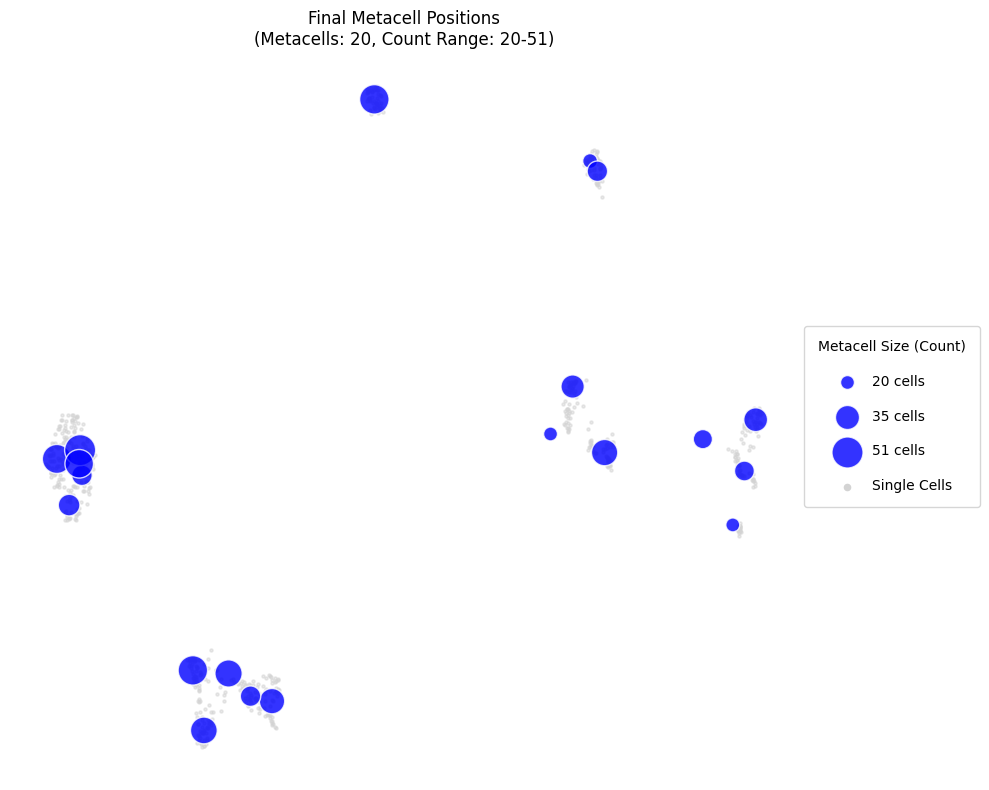

In [15]:


# ==========================================
# 7 - 10. 后续评估与可视化
# ==========================================
print("\n>>> 7-10. 绘图与评估...")
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=100)


In [16]:
hdata.metacells

,total_depth,cell_count,mean_depth,dominant_label
metacell,,,,
0,46071928,38,1.212419e+06,Sst
1,28483243,42,6.781725e+05,Pvalb
2,61821976,47,1.315361e+06,OPC
3,35907724,29,1.238197e+06,L23
4,35758455,29,1.233050e+06,Pvalb
5,40311060,31,1.300357e+06,L23
6,47860502,41,1.167329e+06,Vip
7,63787251,46,1.386679e+06,L4
8,37326622,51,7.318945e+05,L4



正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.7471
模型准确率 (Accuracy)      : 0.7286
全局加权分 (Global Score)  : 0.5876
过度融合指标 (WCOS)       : 0.9486
Hub 权重不纯度 (HWIS)     : 0.9846
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


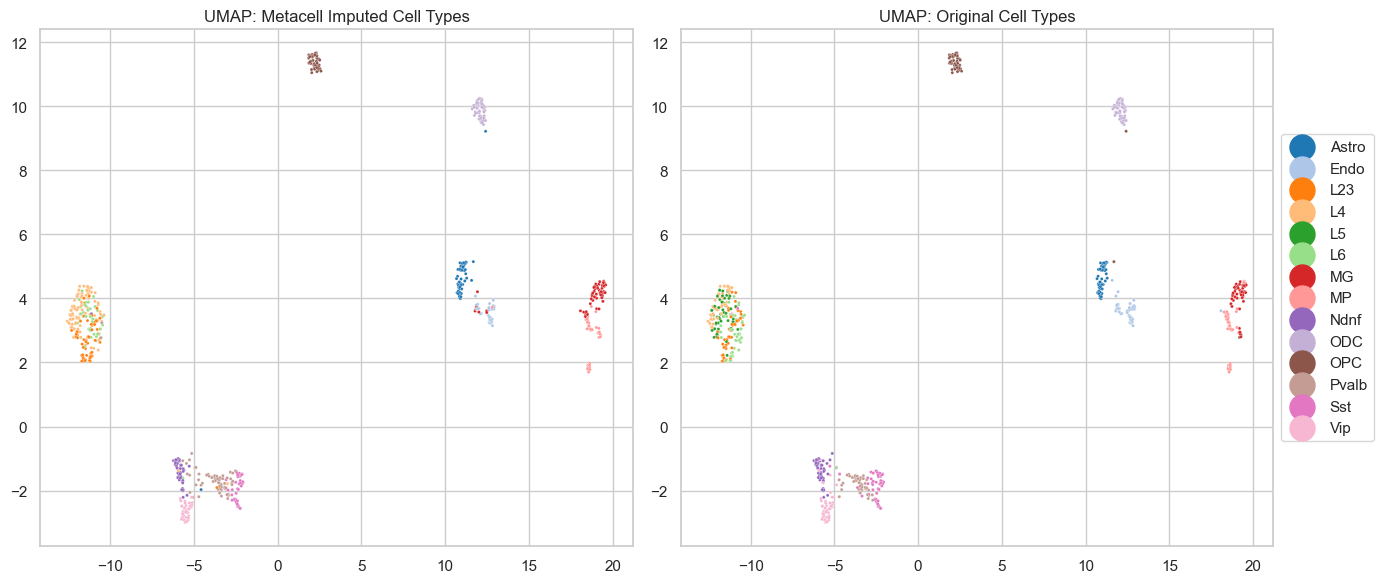


🎉 全流程运行完毕！


In [17]:
# 执行评估
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])

# 最终对比图
sk.pl.plot_umap_comparison(hdata, resolution=500000)

print("\n🎉 全流程运行完毕！")

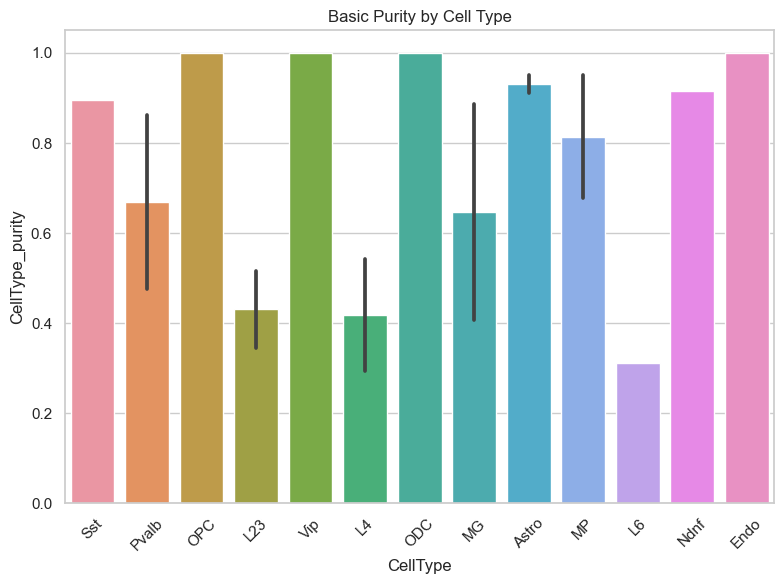

In [18]:
sk.pl.plot_basic_purity(hdata,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


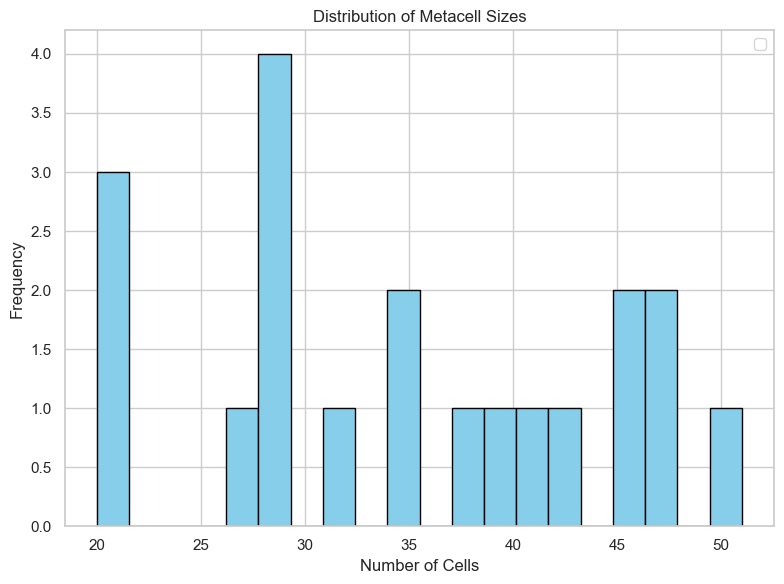

In [19]:
sk.pl.plot_metacell_sizes(hdata,)

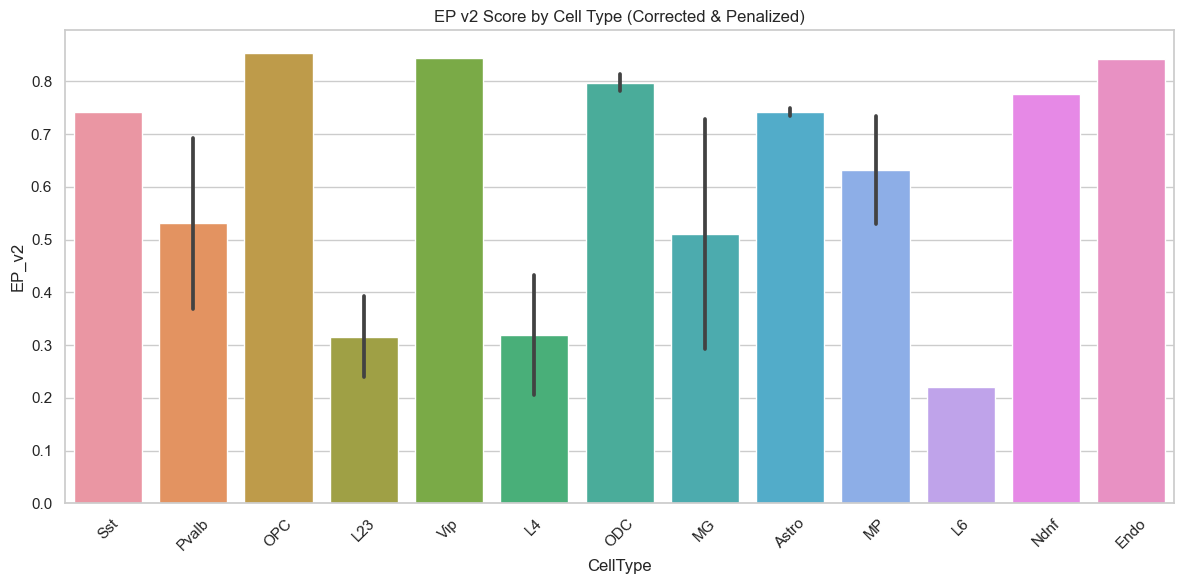

In [20]:
sk.pl.plot_ep_score(hdata)

In [21]:
hdata.obs

,depth,label,metacell
0,1750801,MG,10
1,1927313,Pvalb,4
2,382026,Pvalb,1
3,1391235,L23,5
4,1003154,MG,12
...,...,...,...
695,1356998,Vip,6
696,460106,L4,8
697,989977,MP,12
698,454577,L5,15


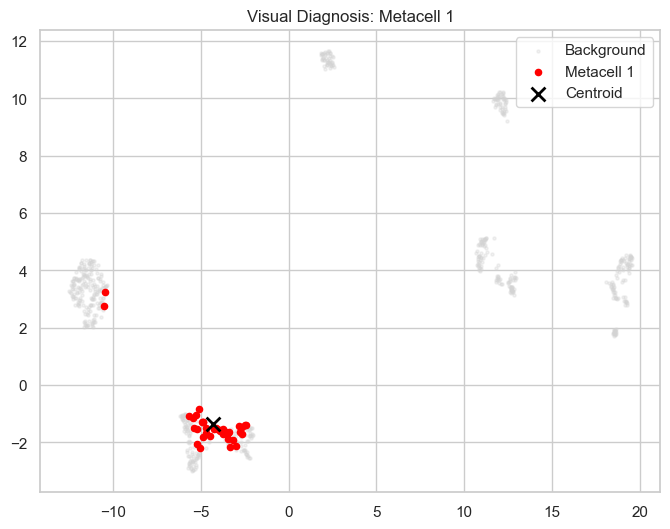

In [22]:
sk.pl.plot_specific_metacell(hdata, metacell_id=1, resolution=500000)


In [23]:
sk.tl.aggregate_metacell_pairs(hdata,  n_jobs=2, force_aggregate=False, 
                             convert_to_cool=True, convert_to_mcool=True,
                             resolution=10000, mcool_resolutions=[ 50000, 100000,500000, 1000000,2000000], verbose=True)
# ,2000000

>>> 未检测到基础属性或被强制刷新，正在统计 Metacell 属性...
>>> 分配发生改变或被强制重跑，正在重新聚合并覆盖历史 pairs 文件...


Aggregating Pairs: 100%|██████████| 20/20 [01:10<00:00,  3.54s/it]


开始转换为 .mcool (包含分辨率: 50000,100000,500000,1000000,2000000, 并行数: 2)...


Cool -> MCool:  12%|█▎        | 5/40 [00:30<03:08,  5.40s/it]

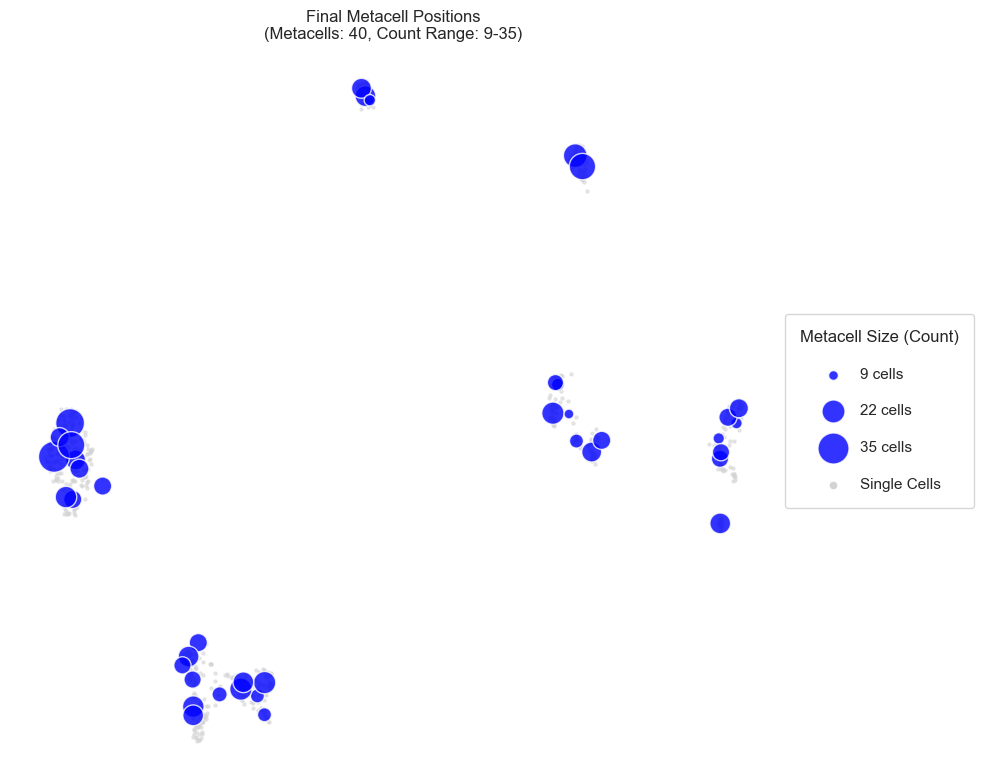

In [ ]:
sk.pl.plot_metacells(hdata,resolution=500000)

In [ ]:
chrom = 'chr2'
start = 169600000
end = 173600000
resolution = 50000

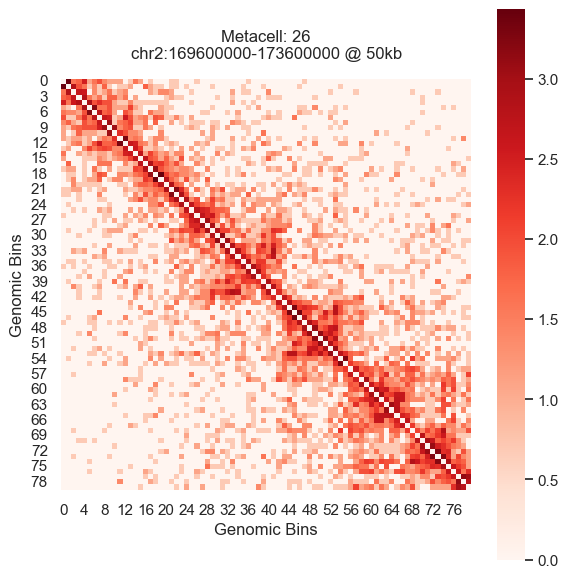

array([[0.        , 3.40119738, 1.60943791, ..., 0.        , 0.        ,
        0.        ],
       [3.40119738, 0.        , 2.83321334, ..., 0.        , 0.        ,
        0.        ],
       [1.60943791, 2.83321334, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 3.13549422,
        2.99573227],
       [0.        , 0.        , 0.        , ..., 3.13549422, 0.        ,
        2.77258872],
       [0.        , 0.        , 0.        , ..., 2.99573227, 2.77258872,
        0.        ]])

In [ ]:

sk.pl.plot_metacell_heatmap(hdata=hdata, 
                            metacell_id=26,
                            chrom=chrom,
                            balance=False,
                            resolution=50000,
                            start=start,
                            log1p=True,
                            end=end)

In [ ]:
hdata.metacells

,total_depth,cell_count,mean_depth,dominant_label,CellType_purity,w_min,w_max,P_adj,EP_v2
metacell,,,,,,,,,
0,30523520,19,1.606501e+06,OPC,1.000000,0.770584,1.0,1.000000,0.770584
1,11580609,16,7.237881e+05,Ndnf,0.375000,0.750000,1.0,0.326923,0.245192
2,22015738,18,1.223097e+06,OPC,1.000000,0.764298,1.0,1.000000,0.764298
3,20340859,18,1.130048e+06,L23,0.500000,0.764298,1.0,0.461538,0.352753
4,15904012,12,1.325334e+06,Sst,0.750000,0.711325,1.0,0.730769,0.519814
5,21070161,16,1.316885e+06,L6,0.812500,0.750000,1.0,0.798077,0.598558
6,9458820,13,7.276015e+05,Vip,0.461538,0.722650,1.0,0.420118,0.303598
7,46448855,35,1.327110e+06,L4,0.571429,0.830969,1.0,0.538462,0.447445
8,23346505,31,7.531131e+05,L4,0.419355,0.820395,1.0,0.374690,0.307394


In [ ]:
hdata

HData object with 700 cells and 40 metacells
    resolutions: [50000, 100000, 500000, 1000000, 2000000]
    obs: ['depth', 'label', 'metacell']
    views_pca: [50000, 100000, 500000, 1000000]
    views_umap: [50000, 100000, 500000, 1000000]
    views_embedding: [50000, 100000, 500000, 1000000]
    uns keys: ['recommended_k', 'purity_df', 'metrics', 'eval_df_cache', 'avg_size_cache', 'thre_cache', 'accuracy', 'global_score']
    metacells: ['total_depth', 'cell_count', 'mean_depth', 'dominant_label', 'CellType_purity', 'w_min', 'w_max', 'P_adj', 'EP_v2']
    metacell_data keys: ['pairs', 'cool', 'mcool']
    model: MultiViewSEACells (trained: True)

共找到 2 个属于 'ODC' 的 Metacells, 准备渲染...


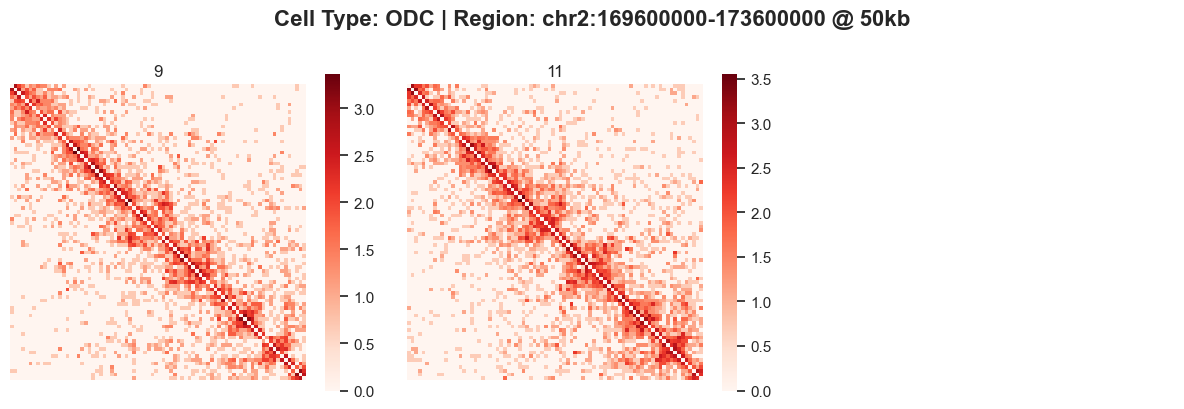

In [ ]:
sk.pl.plot_celltype_heatmaps(hdata=hdata,
                             chrom=chrom,
                             cell_type='ODC',
                            balance=False,
                            resolution=50000,
                            start=start,
                            cell_type_col='dominant_label',
                            ncols=3,
                            end=end)

共找到 1 个属于 'L5' 的 Metacells, 准备渲染...


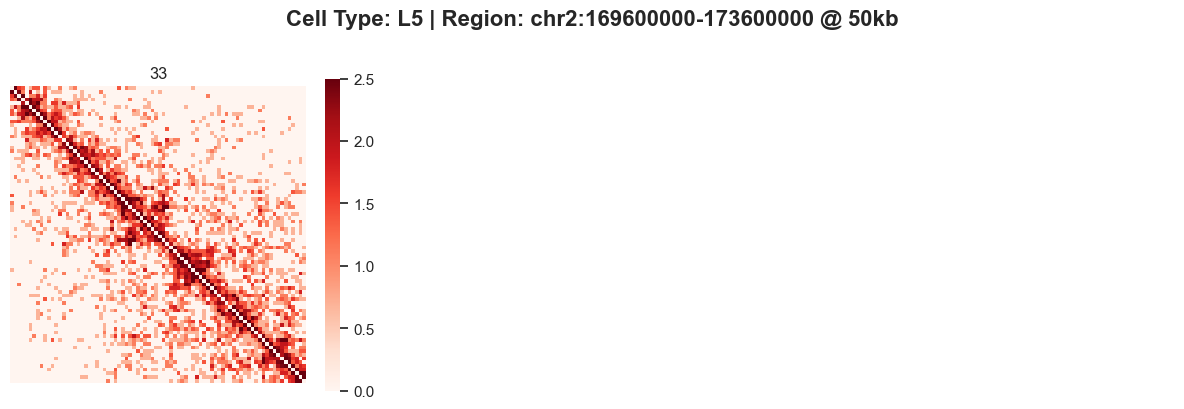

In [ ]:
sk.pl.plot_celltype_heatmaps(hdata=hdata,
                             chrom=chrom,
                             cell_type='L5',
                            balance=False,
                            resolution=50000,
                            start=start,
                            cell_type_col='dominant_label',
                            ncols=3,
                            vmax=2.5,
                            log1p=True,
                            fill_diagonal_zero=True,
                            end=end)

In [ ]:
hdata

HData object with 700 cells and 40 metacells
    resolutions: [50000, 100000, 500000, 1000000, 2000000]
    obs: ['depth', 'label', 'metacell']
    views_pca: [50000, 100000, 500000, 1000000]
    views_umap: [50000, 100000, 500000, 1000000]
    views_embedding: [50000, 100000, 500000, 1000000]
    uns keys: ['recommended_k', 'purity_df', 'metrics', 'eval_df_cache', 'avg_size_cache', 'thre_cache', 'accuracy', 'global_score']
    metacells: ['total_depth', 'cell_count', 'mean_depth', 'dominant_label', 'CellType_purity', 'w_min', 'w_max', 'P_adj', 'EP_v2']
    metacell_data keys: ['pairs', 'cool', 'mcool']
    model: MultiViewSEACells (trained: True)

In [ ]:
hdata.uns.keys()

dict_keys(['recommended_k', 'purity_df', 'metrics', 'eval_df_cache', 'avg_size_cache', 'thre_cache', 'accuracy', 'global_score'])

In [ ]:
hdata.model.waypoints

array([213,  22, 467, 381, 674, 247, 130, 294, 206, 280, 166, 432, 578,
       256,  21, 149,  97, 406, 505,  83, 595, 385, 122, 329, 253, 570,
       395, 465, 352, 494])

In [ ]:
hdata.model._eval_df_cache